In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram,linkage,fcluster


In [3]:
df=pd.read_csv("sales_data_sample.csv",encoding='ISO-8859-1')

In [4]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [5]:
features=df[['SALES','QUANTITYORDERED','PRICEEACH']]
scaler=StandardScaler()
scaled_features=scaler.fit_transform(features)

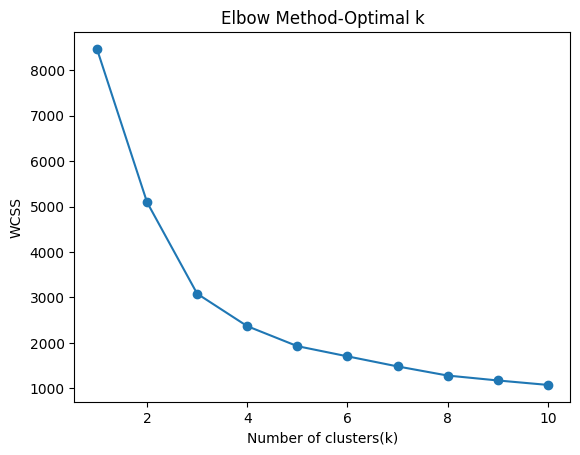

In [6]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of clusters(k)")
plt.ylabel("WCSS")
plt.title("Elbow Method-Optimal k")
plt.show()

In [7]:
kmeans=KMeans(n_clusters=3,random_state=42)
df['KMeans_Cluster']=kmeans.fit_predict(scaled_features)

print(df[['SALES','QUANTITYORDERED','PRICEEACH','KMeans_Cluster']].head())

     SALES  QUANTITYORDERED  PRICEEACH  KMeans_Cluster
0  2871.00               30      95.70               2
1  2765.90               34      81.35               2
2  3884.34               41      94.74               1
3  3746.70               45      83.26               1
4  5205.27               49     100.00               1


In [8]:
linked = linkage(scaled_features, method='ward')


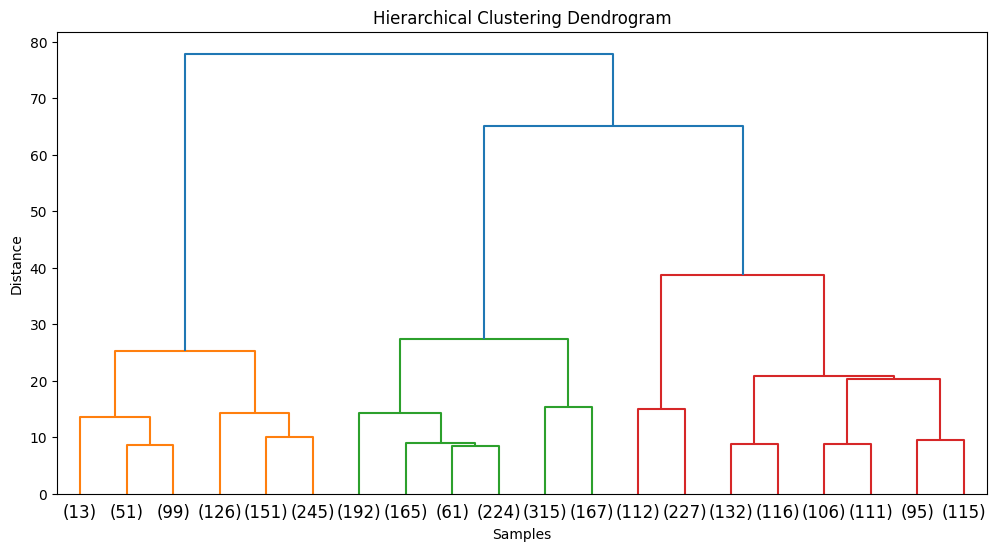

In [9]:
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


In [10]:
df['HierCluster'] = fcluster(linked, 3, criterion='maxclust')


In [11]:
print(df[['SALES', 'QUANTITYORDERED', 'PRICEEACH', 'KMeans_Cluster', 'HierCluster']].head())


     SALES  QUANTITYORDERED  PRICEEACH  KMeans_Cluster  HierCluster
0  2871.00               30      95.70               2            2
1  2765.90               34      81.35               2            2
2  3884.34               41      94.74               1            1
3  3746.70               45      83.26               1            3
4  5205.27               49     100.00               1            1
